<a target="_blank" href="https://colab.research.google.com/github/genomicsxai/alphagenome-pytorch/blob/main/examples/notebooks/variant_scoring.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# AlphaGenome Variant Scoring Tutorial

This notebook demonstrates how to score genetic variants using the AlphaGenome PyTorch model.

## Prerequisites

Before running this notebook, you need to:

1. **Download required files** - See [variant_scoring/README.md](../../src/alphagenome_pytorch/variant_scoring/README.md) for detailed instructions:
   - Model weights (`ag_pytorch_model.pt`)
   - Track means (`track_means.pt`)
   - Reference genome (hg38.fa with .fai index)
   - Gene annotations (gencode.v46.annotation.parquet)
   - PolyA annotations (gencode.v46.polyAs.linked.parquet) - optional
   - Track metadata (track_metadata.parquet)

2. **Set up annotation files** - Run the preprocessing scripts:
   ```bash
   # See README for download URLs and conversion commands
   python scripts/convert_gtf_to_parquet.py --input gencode.v46.annotation.gtf --output gencode.v46.annotation.parquet
   python scripts/preprocess_polya.py --metadata gencode.v46.metadata.PolyA_feature --gtf gencode.v46.annotation.parquet --output gencode.v46.polyAs.linked.parquet
   ```

3. **Update file paths** in the cells below to match your local setup.

## 1. Import Required Modules

In [1]:
import torch
from alphagenome_pytorch.model import AlphaGenome
from alphagenome_pytorch.config import DtypePolicy
from alphagenome_pytorch.variant_scoring import (
    VariantScoringModel, Variant, Interval,
    CenterMaskScorer, OutputType, AggregationType,
    get_recommended_scorers,
)

## 2. Load AlphaGenome Model

We load the model in **float32** precision for production use. This provides:
- Cleaner signals with less quantization noise
- Standard precision for downstream analysis

**Note**: Use `compute_dtype=torch.bfloat16` only if you need exact parity with the JAX/API reference for testing or to fit the full model (such as 1MB context) on smaller hardware.

In [2]:
TORCH_WEIGHTS_PATH = '../../ag_pytorch_model.pth




'


# Initialize model in float32 (production use)
model = AlphaGenome(num_organisms=2, dtype_policy=DtypePolicy.full_float32())
checkpoint = torch.load(TORCH_WEIGHTS_PATH, map_location='cpu')
model.load_state_dict(checkpoint['state_dict'])

model.eval()

# Move to GPU if available
if torch.cuda.is_available():
    model.cuda()
    print("✓ Model loaded on GPU")
else:
    print("✓ Model loaded on CPU")

✓ Model loaded on GPU


## 3. Create Variant Scoring Model

The `VariantScoringModel` wraps the base model with variant scoring functionality.
It requires:
- **fasta_path**: Reference genome for sequence extraction
- **gtf_path**: Gene annotations for gene-based scorers
- **polya_path**: PolyA sites for PolyadenylationScorer (optional)
- **track_metadata**: Track names and metadata for tidy output

In [42]:
# Update these paths to match your local setup
# See README for instructions on downloading and converting annotations
scoring_model = VariantScoringModel(
    model,
    fasta_path="../../data/annotations/hg38.fa",
    gtf_path="../../data/annotations/gencode.v46.annotation.parquet",
    polya_path="../../data/annotations/gencode.v46.polyAs.linked.parquet",  # Optional
    default_organism="human",
)

# Load track metadata for annotated results
# These can be extracted from the model using scripts/extract_track_metadata.py
scoring_model.load_all_metadata('../../track_metadata.parquet')
print("✓ Scoring model initialized")

✓ Scoring model initialized


## 4. Define Variant and Interval

- **Variant**: Uses VCF-style 1-based coordinates (chrom:pos:ref>alt)
- **Interval**: Model requires 131,072bp (128KB) centered on the variant

In [4]:
# Define a test variant (chr22:36201698:A>C)
variant = Variant.from_str('chr22:36201698:A>C')

# Create interval centered on variant
interval = Interval.centered_on('chr22', 36201698, width="100KB")

print(f"Variant: {variant}")
print(f"Interval: {interval}")
print(f"Interval width: {interval.width:,}bp")

Variant: chr22:36201698:A>C
Interval: chr22:36136162-36267234
Interval width: 131,072bp


## 5. Score Variant with Recommended Scorers

The `get_recommended_scorers()` function returns 19 pre-configured scorers that match the official AlphaGenome API:

- **CenterMaskScorer** (12 configs): ATAC, DNase, CAGE, PRO-cap, ChIP-TF, ChIP-histone
- **GeneMaskLFCScorer** (1): RNA-seq log fold change
- **GeneMaskActiveScorer** (1): RNA-seq active allele
- **GeneMaskSplicingScorer** (2): Splice sites and usage
- **SpliceJunctionScorer** (1): Junction disruption
- **ContactMapScorer** (1): 3D chromatin contacts
- **PolyadenylationScorer** (1): Polyadenylation QTLs (human only)

In [5]:
# Score variant with all 19 recommended scorers
scores = scoring_model.score_variant(
    interval=interval,
    variant=variant,
    scorers=get_recommended_scorers('human'),
    organism='human',
    to_cpu=True,  # Move results to CPU for analysis
)

print(f"✓ Scored variant with {len(scores)} scorers")

✓ Scored variant with 19 scorers


## 6. Convert Results to Tidy DataFrame

The `tidy_scores()` method converts results to a long-format DataFrame with:
- One row per track
- Variant and gene metadata
- Track names and metadata (biosample, assay type, etc.)
- Raw scores and quantile-normalized scores

In [6]:
# Convert to tidy DataFrame
df = scoring_model.tidy_scores(scores)

print(f"Shape: {df.shape}")
df.head()

Shape: (38780, 21)


,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,...,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,transcription_factor,histone_mark,gtex_tissue,raw_score,track_index
0,chr22:36201698:A>C,chr22:36136162-36267234,None,None,None,None,NaN,NaN,atac,"CenterMaskScorer(output=atac, width=501, agg=d...",...,.,ATAC-seq,CL:0000084,T-cell,primary_cell,None,None,None,-0.062569,0
1,chr22:36201698:A>C,chr22:36136162-36267234,None,None,None,None,NaN,NaN,atac,"CenterMaskScorer(output=atac, width=501, agg=d...",...,.,ATAC-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,None,None,None,0.004393,1
2,chr22:36201698:A>C,chr22:36136162-36267234,None,None,None,None,NaN,NaN,atac,"CenterMaskScorer(output=atac, width=501, agg=d...",...,.,ATAC-seq,CL:0000236,B cell,primary_cell,None,None,None,0.007725,2
3,chr22:36201698:A>C,chr22:36136162-36267234,None,None,None,None,NaN,NaN,atac,"CenterMaskScorer(output=atac, width=501, agg=d...",...,.,ATAC-seq,CL:0000623,natural killer cell,primary_cell,None,None,None,-0.057389,3
4,chr22:36201698:A>C,chr22:36136162-36267234,None,None,None,None,NaN,NaN,atac,"CenterMaskScorer(output=atac, width=501, agg=d...",...,.,ATAC-seq,CL:0000624,"CD4-positive, alpha-beta T cell",primary_cell,None,None,None,-0.059652,4


## 7. Explore Results

Let's examine the scores by output type and scorer.

In [7]:
# View summary by scorer
print("Scores by scorer:")
print(df.groupby('variant_scorer')['raw_score'].agg(['count', 'mean', 'std']))

Scores by scorer:
                                                    count         mean  \
variant_scorer                                                           
CenterMaskScorer(output=atac, width=501, agg=ac...    256    33.684661   
CenterMaskScorer(output=atac, width=501, agg=di...    256    -0.002459   
CenterMaskScorer(output=cage, width=501, agg=ac...    640   205.459092   
CenterMaskScorer(output=cage, width=501, agg=di...    640    -2.310507   
CenterMaskScorer(output=chip_histone, width=200...   1152  2520.110189   
CenterMaskScorer(output=chip_histone, width=200...   1152    -0.142199   
CenterMaskScorer(output=chip_tf, width=501, agg...   1664   539.264916   
CenterMaskScorer(output=chip_tf, width=501, agg...   1664     0.020639   
CenterMaskScorer(output=dnase, width=501, agg=a...    384    75.993788   
CenterMaskScorer(output=dnase, width=501, agg=d...    384     0.027010   
CenterMaskScorer(output=procap, width=501, agg=...    128    18.222188   
CenterMaskScorer(out

## 8. Visualize variant

/scratch/users/mkjellbe/micromamba/envs/alphagenome/lib/python3.12/site-packages/alphagenome/data/transcript.py:662: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chromosome, dfc in df.groupby('Chromosome')
/scratch/users/mkjellbe/micromamba/envs/alphagenome/lib/python3.12/site-packages/alphagenome/data/transcript.py:662: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for chromosome, dfc in df.groupby('Chromosome')


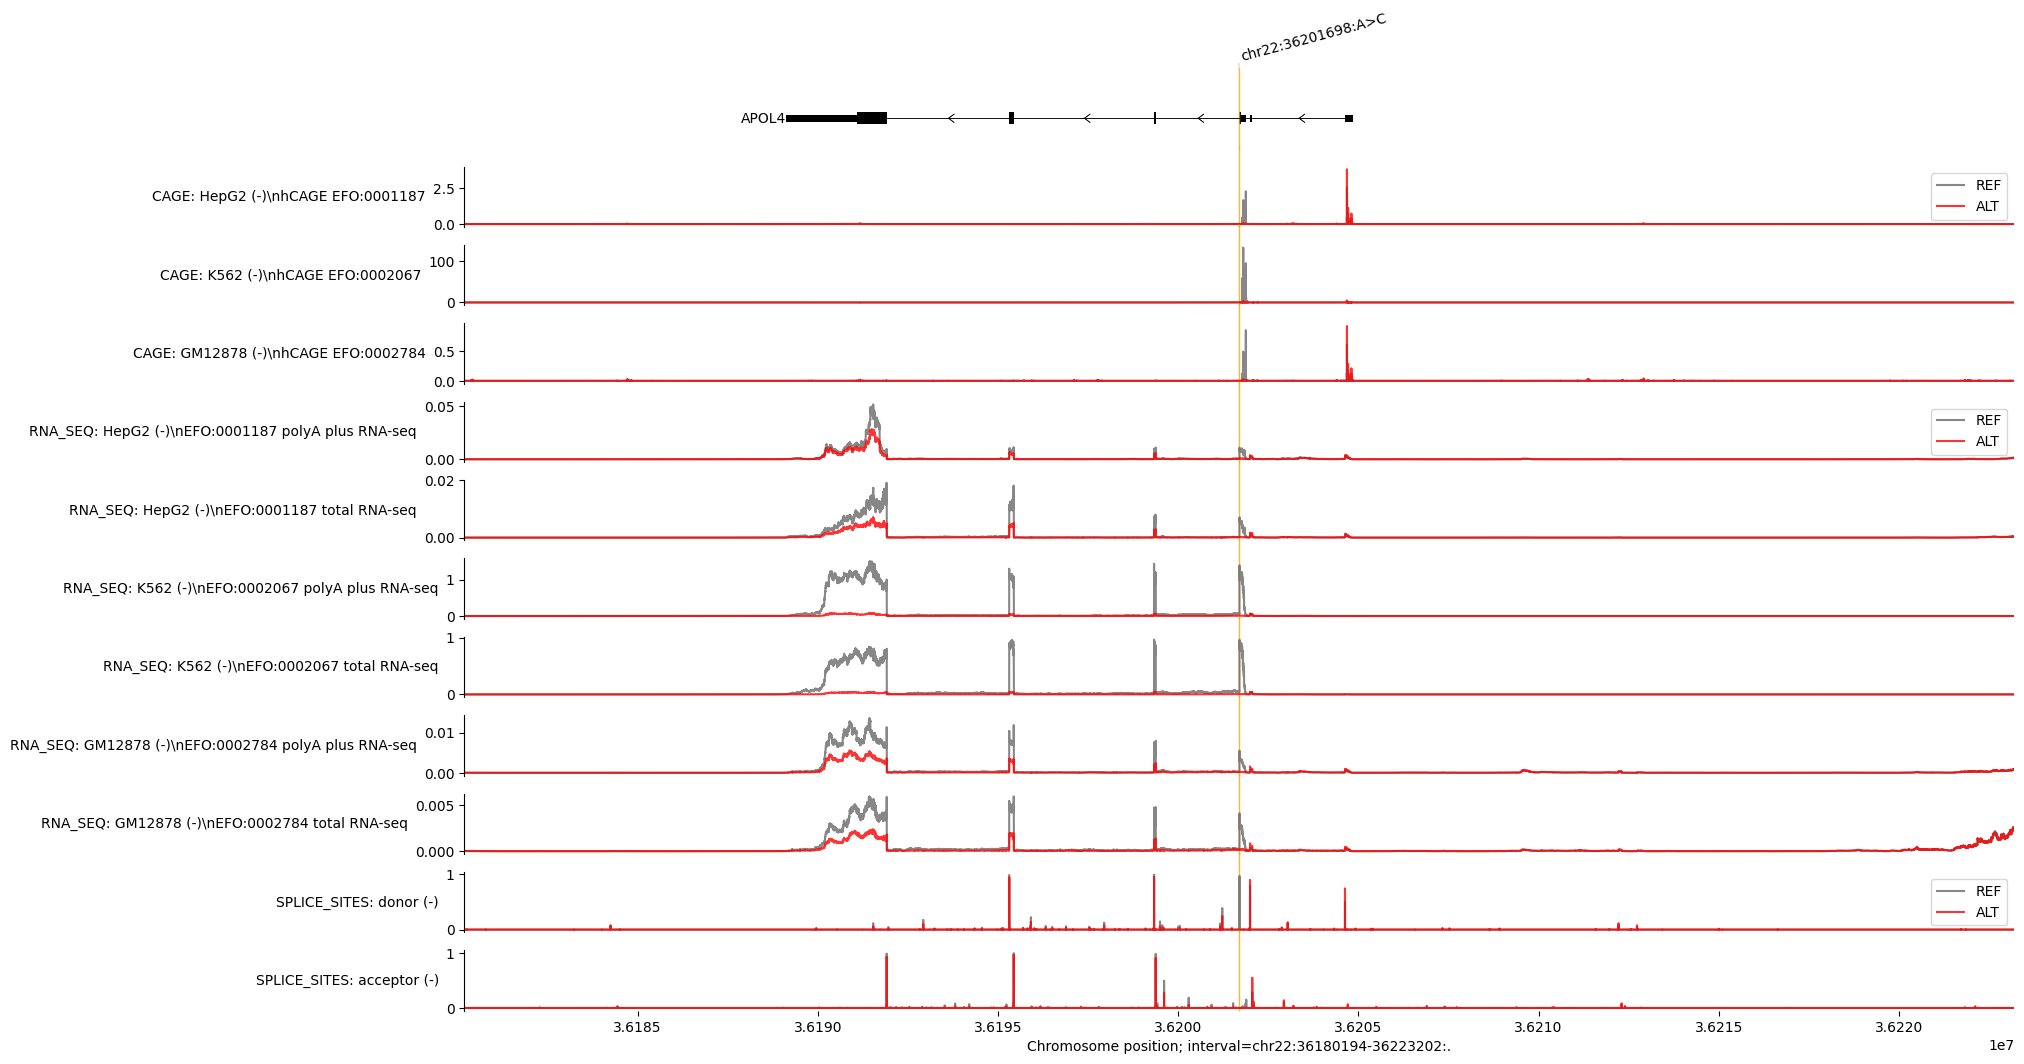

In [8]:
from alphagenome_pytorch.variant_scoring import visualize_variant

# Visualize variant effects (matching Colab defaults)
visualize_variant(
    scoring_model,
    interval,
    variant,
    resolution=1, # 1bp resolution
    # Ontology filtering
    ontology_terms=['EFO:0001187', 'EFO:0002067', 'EFO:0002784'],  # HepG2, K562, GM12878
    # Gene annotation
    plot_gene_annotation=True,
    plot_longest_transcript_only=True,
    # Output types
    plot_cage=True,
    plot_rna_seq=True,
    plot_splice_sites=True,
    plot_atac=False,
    plot_dnase=False,
    plot_chip_histone=False,
    plot_chip_tf=False,
    plot_splice_site_usage=False,
    # Strand filtering
    filter_to_positive_strand=False,
    filter_to_negative_strand=True,
    # Plot options
    plot_interval_width=43008,
    plot_interval_shift=0,
);

## 8. Custom Scorer Example

You can create custom scorers with different parameters. Here's an example using ATAC-seq with a wider window:

In [9]:
# Create a custom scorer
custom_scorer = CenterMaskScorer(
    requested_output=OutputType.ATAC,
    width=2001,  # Wider window (2kb centered on variant)
    aggregation_type=AggregationType.DIFF_LOG2_SUM,  # Log fold change
    resolution=1,  # 1bp resolution for fine detail
)

# Score with custom scorer
custom_scores = scoring_model.score_variant(
    interval=interval,
    variant=variant,
    scorers=[custom_scorer],
    organism='human',
    to_cpu=True,
)

# Convert to DataFrame
custom_df = scoring_model.tidy_scores(custom_scores)
print(f"Custom scorer results: {custom_df.shape[0]} tracks")
custom_df.head()

Custom scorer results: 256 tracks


,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,...,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,transcription_factor,histone_mark,gtex_tissue,raw_score,track_index
0,chr22:36201698:A>C,chr22:36136162-36267234,None,None,None,None,None,None,atac,"CenterMaskScorer(output=atac, width=2001, agg=...",...,.,ATAC-seq,CL:0000084,T-cell,primary_cell,None,None,None,-0.039216,0
1,chr22:36201698:A>C,chr22:36136162-36267234,None,None,None,None,None,None,atac,"CenterMaskScorer(output=atac, width=2001, agg=...",...,.,ATAC-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,None,None,None,-0.001569,1
2,chr22:36201698:A>C,chr22:36136162-36267234,None,None,None,None,None,None,atac,"CenterMaskScorer(output=atac, width=2001, agg=...",...,.,ATAC-seq,CL:0000236,B cell,primary_cell,None,None,None,0.022250,2
3,chr22:36201698:A>C,chr22:36136162-36267234,None,None,None,None,None,None,atac,"CenterMaskScorer(output=atac, width=2001, agg=...",...,.,ATAC-seq,CL:0000623,natural killer cell,primary_cell,None,None,None,-0.029534,3
4,chr22:36201698:A>C,chr22:36136162-36267234,None,None,None,None,None,None,atac,"CenterMaskScorer(output=atac, width=2001, agg=...",...,.,ATAC-seq,CL:0000624,"CD4-positive, alpha-beta T cell",primary_cell,None,None,None,-0.026243,4


## 9. Gene-Based Scoring

Gene-based scorers return one score per gene overlapping the interval:

In [10]:
from alphagenome_pytorch.variant_scoring.scorers import GeneMaskLFCScorer

# Create gene-level scorer
gene_scorer = GeneMaskLFCScorer(OutputType.RNA_SEQ)

# Score variant
gene_scores = scoring_model.score_variant(
    interval=interval,
    variant=variant,
    scorers=[gene_scorer],
    organism='human',
    to_cpu=True,
)

# Convert to DataFrame and view genes
gene_df = scoring_model.tidy_scores(gene_scores)
print(f"Found {gene_df['gene_id'].nunique()} genes in interval")
gene_df[['gene_name', 'gene_id', 'raw_score']].drop_duplicates('gene_id')

Found 12 genes in interval


,gene_name,gene_id,raw_score
0,MTCO1P20,ENSG00000233764,0.005431
768,MTCO2P20,ENSG00000231576,0.004852
1536,MTATP6P20,ENSG00000237948,0.001218
2304,MTCO3P20,ENSG00000225557,0.002390
3072,MTCYBP34,ENSG00000237129,0.003161
3840,MTND1P10,ENSG00000229088,-0.000389
4608,ENSG00000288778,ENSG00000288778,0.040432
5376,APOL1,ENSG00000100342,0.025417
6144,ENSG00000279805,ENSG00000279805,0.001093
6912,APOL3,ENSG00000128284,0.002691


## Next Steps

- **Batch scoring**: Score multiple variants by looping over variant list
- **In-silico mutagenesis**: Use `score_ism_variants()` to score all possible SNVs in a window
- **Visualization**: See the variant scoring README for plotting utilities
- **Custom analysis**: Filter by effect size, biosample type, or genomic context

For more details, see:
- [Variant Scoring README](../../src/alphagenome_pytorch/variant_scoring/README.md)
- [In-Silico Mutagenesis Notebook](./in_silico_mutagenesis.ipynb)